Instalación de Stable Baselines3

In [2]:
!pip install "stable-baselines3[extra]>=2.0.0a4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 39.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [2]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from typing import Optional
from stable_baselines3 import DQN

Función de utilidad para visualizar los parámetros por episodio

In [4]:
import matplotlib.pyplot as plt
from stable_baselines3.common.callbacks import BaseCallback


class CustomCallback(BaseCallback):
    def __init__(self, verbose=0):
        super(CustomCallback, self).__init__(verbose)
        self.episode_lengths = []
        self.episode_rewards = []
        self.exploration_rates = []
        self.losses = []
        self.learning_rates = []
        self.timesteps = []
        self.current_episode_length = 0
        self.current_episode_reward = 0

    def _on_step(self) -> bool:
        self.current_episode_length += 1
        self.current_episode_reward += self.locals['rewards'][0]

        if self.locals['dones'][0]:
            self.episode_lengths.append(self.current_episode_length)
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_length = 0
            self.current_episode_reward = 0
        # Store additional data
        self.exploration_rates.append(self.model.exploration_rate)
        self.losses.append(self.logger.name_to_value['train/loss'])
        self.learning_rates.append(self.logger.name_to_value['train/learning_rate'])
        self.timesteps.append(self.num_timesteps)

        return True

    def plot_results(self):
        plt.figure(figsize=(12, 6))
        plt.subplot(2, 2, 1)
        plt.plot(self.episode_lengths)
        plt.xlabel('Episode')
        plt.ylabel('Length')
        plt.title('Episode Length Over Time')

        plt.subplot(2, 2, 2)
        plt.plot(self.episode_rewards)
        plt.xlabel('Episode')
        plt.ylabel('Reward')
        plt.title('Episode Reward Over Time')

        plt.subplot(2, 2, 3)
        plt.plot(self.exploration_rates)
        plt.xlabel('Timestep')
        plt.ylabel('Exploration Rate')
        plt.title('Exploration Rate Over Time')

        plt.subplot(2, 2, 4)
        plt.plot(self.losses)
        plt.xlabel('Timestep')
        plt.ylabel('Loss')
        plt.title('Loss Over Time')

        plt.tight_layout()
        plt.show()

Instanciar el entorno CliffWalking de Gymnasium


In [5]:
# Crear el entorno con render_mode="ansi" para visualizar en texto
env = gym.make("CliffWalking-v0", render_mode="ansi")

Ajustar los hiperparámetros del modelo DQN

In [9]:
# total_timesteps
# Determina la cantidad total de pasos que el agente tomará en el entorno durante el entrenamiento.
total_timesteps = 25000

# Tasa de aprendizaje:
# determina el tamaño de los pasos que la red neuronal toma para actualizar sus pesos durante el entrenamiento.
# Un valor más alto puede acelerar el aprendizaje, pero también puede hacerlo inestable.
# Un valor más bajo puede hacer que el aprendizaje sea más lento, pero más estable.
learning_rate = 0.001

# Gamma:
# También conocido como factor de descuento, determina la importancia de las recompensas futuras en comparación con las recompensas inmediatas.
# Un valor de 1 significa que las recompensas futuras se valoran tanto como las recompensas inmediatas,
# mientras que un valor de 0 significa que solo se consideran las recompensas inmediatas.
gamma = 0.99

# exploration_fraction
# Controla la disminución de la tasa de exploración a lo largo del tiempo.
# Al principio del entrenamiento, el agente explora más para descubrir nuevas estrategias.
# A medida que aprende, la exploración disminuye y el agente se centra en explotar las estrategias aprendidas.
# Un valor de 1 significa que el agente explorará al principio y un valor de 0 significa que no explorará en absoluto.
exploration_fraction = 0.2

# exploration_final_eps
# Define la tasa de exploración mínima que el agente tendrá al final del entrenamiento.
# Incluso después de aprender, es útil mantener una pequeña cantidad de exploración para evitar que el agente se quede atascado en estrategias subóptimas.
exploration_final_eps = 0.01

# batch_size
# Determina la cantidad de muestras de experiencia que se utilizan para cada actualización de la red neuronal.
# Un tamaño de lote más grande puede hacer que el entrenamiento sea más estable, pero también requiere más memoria.
batch_size = 64

# train_freq
# Determina la cantidad de pasos que el agente debe tomar antes de actualizar la red neuronal.
# Un valor más alto puede hacer que el entrenamiento sea más rápido, pero también puede hacerlo inestable.
# Un valor de 4 por ejemplo significa que la red neuronal se actualiza cada 4 pasos del entorno.
train_freq = 4

# target_update_interval
# Determina la frecuencia con la que la red neuronal objetivo se actualiza con los pesos de la red neuronal principal.
# Actualizar la red neuronal objetivo con menos frecuencia puede hacer que el entrenamiento sea más estable.
target_update_interval = 500

# buffer_size
# Determina la capacidad de memoria de experiencia del agente.
# Un tamaño de búfer más grande puede permitir que el agente aprenda de una experiencia más variada.
buffer_size = 100000

In [ ]:
callback = CustomCallback()

# Crear y entrenar el modelo DQN
model = DQN(
    "MlpPolicy",
    env,
    verbose=1,  # Mostrar información en consola
    learning_rate=learning_rate,
    gamma=gamma,
    exploration_fraction=exploration_fraction,
    exploration_final_eps=exploration_final_eps,
    batch_size=batch_size,
    train_freq=train_freq,
    target_update_interval=target_update_interval,
    buffer_size=buffer_size,
)
model.learn(total_timesteps=total_timesteps, callback=callback)

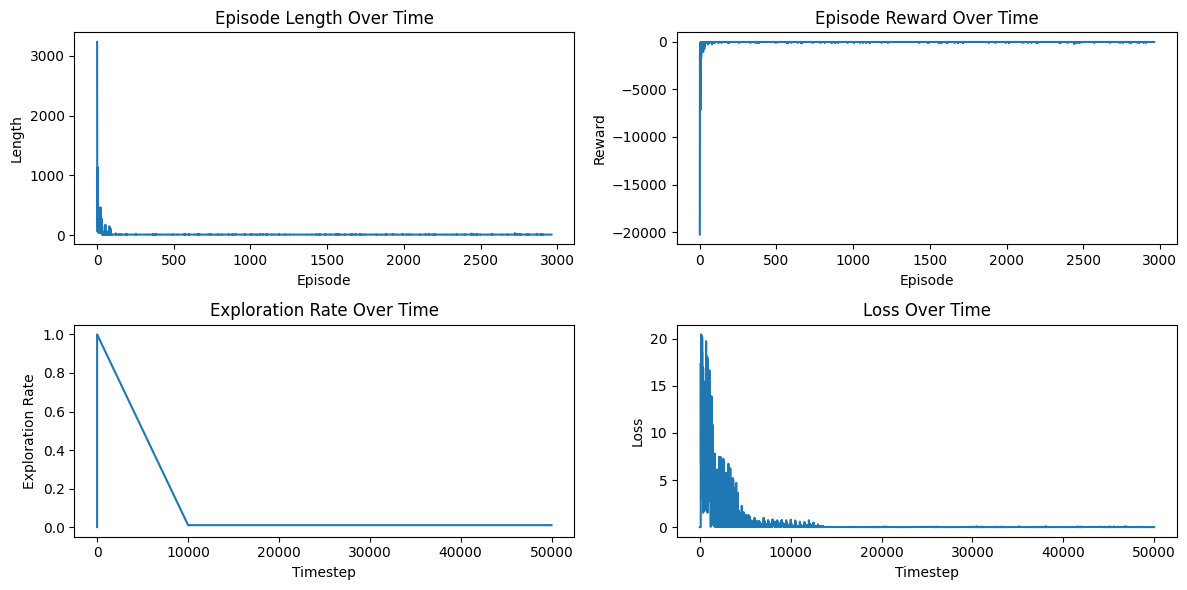

In [112]:
callback.plot_results()

In [113]:
# guardar el modelo entrenado
model.save("dqn_cliffwalking_gym")
# cargar el modelo entrenado
model = DQN.load("dqn_cliffwalking_gym")

In [114]:
# Evaluar el modelo
env = gym.make("CliffWalking-v0", render_mode="human")
obs, _ = env.reset()
done = False

while not done:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action.item())
    done = terminated or truncated
env.close()

Definir el entorno custom CliffWalking

In [6]:
class CliffWalkingEnv(gym.Env):
    def __init__(self):
        super(CliffWalkingEnv, self).__init__()

        # Define action space
        # 4 discrete actions: 0: UP, 1: RIGHT, 2: DOWN, 3: LEFT
        self.action_space = spaces.Discrete(4)

        # Observation space
        # single integer from 0 to 47, representing the grid
        self.observation_space = spaces.Discrete(48)

        self.nrows = 4
        self.ncols = 12
        self.start_state = (3, 0)
        self.goal_state = (3, 11)
        self.cliff = [(3, i) for i in range(1, 11)]

        self.state = self.start_state

    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        self.state = self.start_state
        return self._to_state(self.state), {}

    def step(self, action):
        row, col = self.state

        if action == 0:  # UP
            row = max(row - 1, 0)
        elif action == 1:  # RIGHT
            col = min(col + 1, self.ncols - 1)
        elif action == 2:  # DOWN
            row = min(row + 1, self.nrows - 1)
        elif action == 3:  # LEFT
            col = max(col - 1, 0)

        new_state = (row, col)
        done, reward, truncated, new_state = self.compute_reward(new_state)

        self.state = new_state
        return self._to_state(self.state), reward, done, truncated, {}

    def compute_reward(self, state):
        reward = 0
        done = False
        truncated = False

        if state == self.goal_state:
            reward = 0
            done = True
        elif state in self.cliff:
            reward = -10
            state = self.start_state
        else:
            reward = -1

        return done, reward, truncated, state

    def render(self):
        grid = np.zeros((self.nrows, self.ncols), dtype=str)
        grid[:] = '.'
        grid[3, 1:11] = 'C'  # Cliff
        grid[self.start_state] = 'S'  # Start
        grid[self.goal_state] = 'G'  # Goal
        row, col = self.state
        grid[row, col] = 'A'  # Actor

        print("\n".join([" ".join(row) for row in grid]))
        print()

    def _to_state(self, state):
        return state[0] * self.ncols + state[1]

    def _to_row_col(self, state):
        return state // self.ncols, state % self.ncols

Instanciar el entorno custom CliffWalking

In [10]:
env = CliffWalkingEnv()
callback = CustomCallback()

# Crear y entrenar el modelo DQN
model = DQN(
    "MlpPolicy",
    env,
    verbose=1,  # Mostrar información en consola
    learning_rate=learning_rate,
    gamma=gamma,
    exploration_fraction=exploration_fraction,
    exploration_final_eps=exploration_final_eps,
    batch_size=batch_size,
    train_freq=train_freq,
    target_update_interval=target_update_interval,
    buffer_size=buffer_size,
)
model.learn(total_timesteps=total_timesteps, callback=callback)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 771       |
|    ep_rew_mean      | -1.02e+03 |
|    exploration_rate | 0.39      |
| time/               |           |
|    episodes         | 4         |
|    fps              | 1077      |
|    time_elapsed     | 2         |
|    total_timesteps  | 3083      |
| train/              |           |
|    learning_rate    | 0.001     |
|    loss             | 0.0775    |
|    n_updates        | 745       |
-----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 406      |
|    ep_rew_mean      | -532     |
|    exploration_rate | 0.358    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1077     |
|    time_elapsed     | 3        |
|    total_timesteps  | 3244     |
| train/       

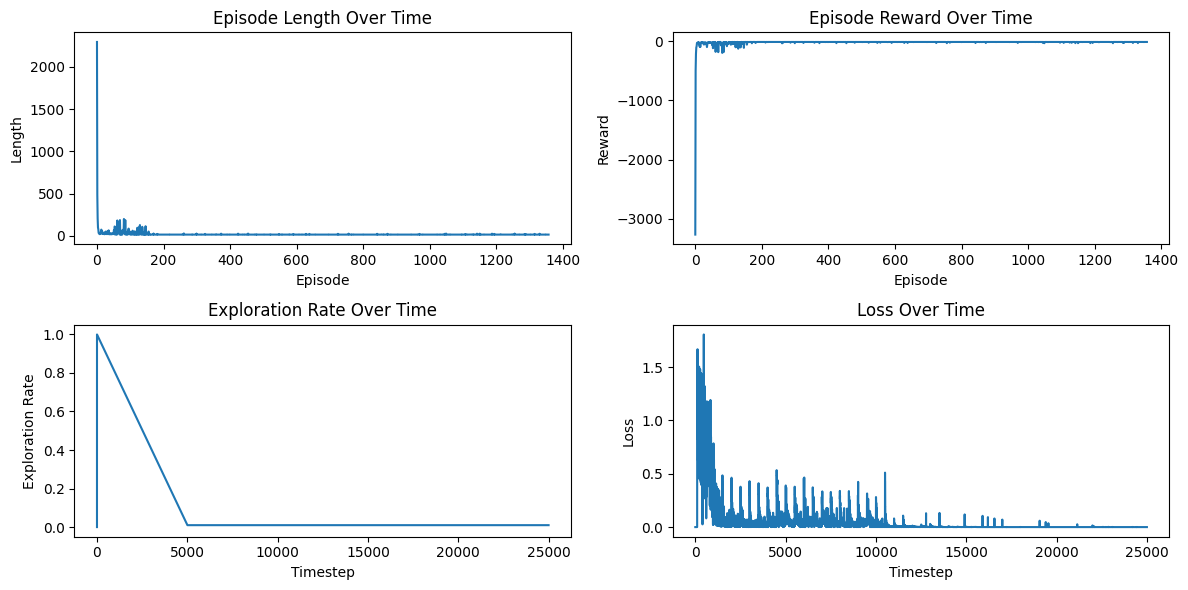

In [11]:
callback.plot_results()

In [120]:
# guardar el modelo entrenado
model.save("dqn_cliffwalking_custom")
# cargar el modelo entrenado
model = DQN.load("dqn_cliffwalking_custom")

In [121]:
# Evaluar el modelo
# env = gym.make("CliffWalking-v0", render_mode="human")
env = CliffWalkingEnv()
obs, _ = env.reset()
done = False

while not done:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action.item())
    done = terminated or truncated

    # Mostrar el entorno en consola
    env.render()

env.close()

. . . . . . . . . . . .
. . . . . . . . . . . .
A . . . . . . . . . . .
S C C C C C C C C C C G

. . . . . . . . . . . .
. . . . . . . . . . . .
. A . . . . . . . . . .
S C C C C C C C C C C G

. . . . . . . . . . . .
. . . . . . . . . . . .
. . A . . . . . . . . .
S C C C C C C C C C C G

. . . . . . . . . . . .
. . . . . . . . . . . .
. . . A . . . . . . . .
S C C C C C C C C C C G

. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . A . . . . . . .
S C C C C C C C C C C G

. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . A . . . . . .
S C C C C C C C C C C G

. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . A . . . . .
S C C C C C C C C C C G

. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . A . . . .
S C C C C C C C C C C G

. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . A . . .
S C C C C C C C C C C G

. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . A . .
S C C C C C C C C C C G

. . . . . . . . . . . .
. . . 